In [1]:
import random

import numpy as np
import torch
import torch.nn as nn
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets
from torchvision.transforms import functional as TF

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

SEED = 100
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device: cuda


In [2]:
import os
cpus = os.cpu_count()
cpus

2

#CONFIG

In [12]:
CONFIG = {
    "data_root": "./data_voc",
    "image_size": 128,
    "batch_size": 8,
    "num_workers": cpus,

    "num_classes": 21,
    "ignore_index": 255,

    "lr": 1e-3,
    "epochs": 20,
    "max_steps_per_epoch": None,
}

print(CONFIG)

{'data_root': './data_voc', 'image_size': 128, 'batch_size': 8, 'num_workers': 2, 'num_classes': 21, 'ignore_index': 255, 'lr': 0.001, 'epochs': 20, 'max_steps_per_epoch': None}


In [6]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


class VOCResizeWrapper(Dataset):
    def __init__(self, voc_dataset, image_size):
        self.voc = voc_dataset
        self.image_size = image_size

    def __len__(self):
        return len(self.voc)

    def __getitem__(self, idx):
        img, mask = self.voc[idx]  # PIL image + PIL mask

        img = img.resize((self.image_size, self.image_size), resample=Image.BILINEAR)
        mask = mask.resize((self.image_size, self.image_size), resample=Image.NEAREST)

        img_t = TF.to_tensor(img)
        img_t = TF.normalize(img_t, IMAGENET_MEAN, IMAGENET_STD)

        mask_np = np.array(mask, dtype=np.uint8)
        mask_t = torch.from_numpy(mask_np).long()  # [H, W]
        return img_t, mask_t


train_base = datasets.VOCSegmentation(
    root=CONFIG["data_root"],
    year="2012",
    image_set="train",
    download=True,
)

val_base = datasets.VOCSegmentation(
    root=CONFIG["data_root"],
    year="2012",
    image_set="val",
    download=True,
)

train_ds = VOCResizeWrapper(train_base, CONFIG["image_size"])
val_ds = VOCResizeWrapper(val_base, CONFIG["image_size"])

train_loader = DataLoader(
    train_ds,
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    num_workers=CONFIG["num_workers"],
    pin_memory=True,
)

val_loader = DataLoader(
    val_ds,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    num_workers=CONFIG["num_workers"],
    pin_memory=True,
)

img_t, mask_t = train_ds[0]
print("img_t:", img_t.shape, "mask_t:", mask_t.shape)
print("mask unique sample:", torch.unique(mask_t)[:10])

100%|██████████| 2.00G/2.00G [01:28<00:00, 22.5MB/s]


img_t: torch.Size([3, 256, 256]) mask_t: torch.Size([256, 256])
mask unique sample: tensor([  0,   1,  15, 255])


#Podgląd danych wejściowych

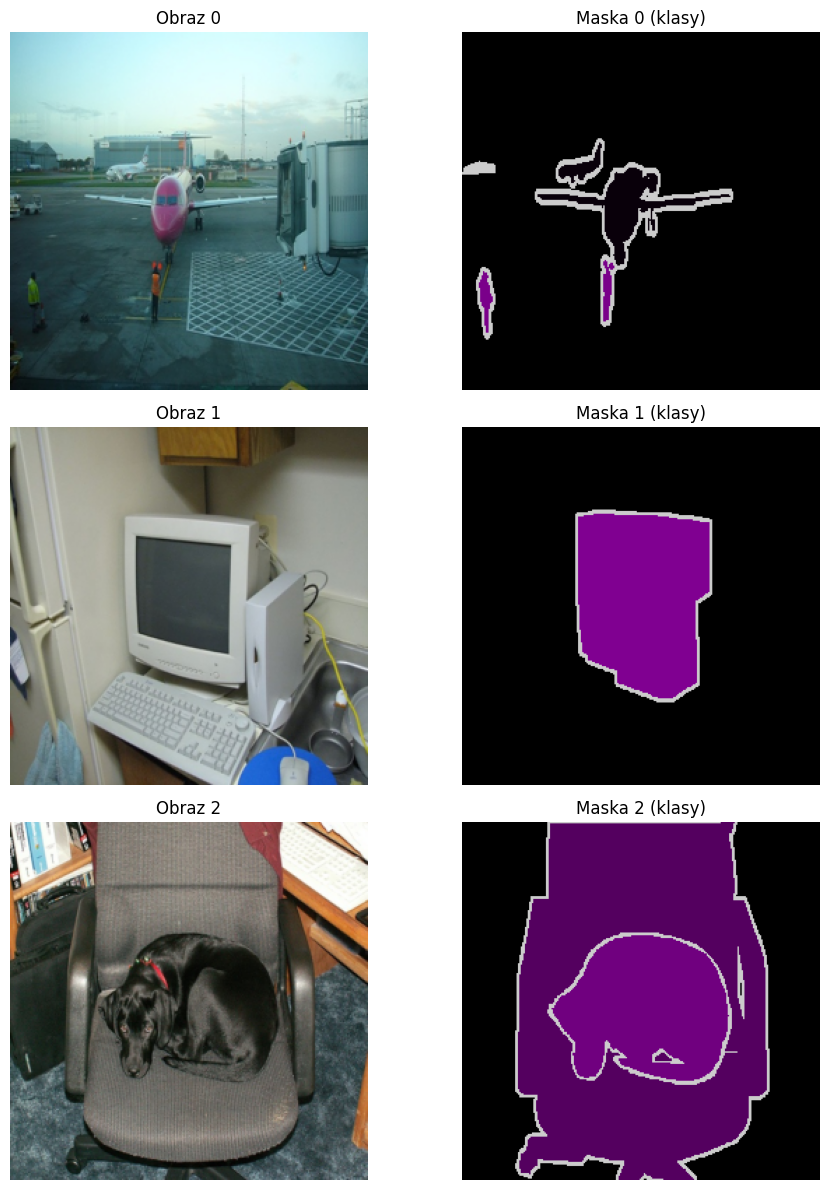

In [7]:
import matplotlib.pyplot as plt

def visualize_input_samples(dataset, num_samples=3):
    fig, axes = plt.subplots(num_samples, 2, figsize=(10, 4 * num_samples))
    for i in range(num_samples):
        img, mask = dataset[i]
        # Denormalizacja obrazu do wyświetlenia
        img_display = img.permute(1, 2, 0).numpy()
        img_display = img_display * IMAGENET_STD + IMAGENET_MEAN
        img_display = np.clip(img_display, 0, 1)

        axes[i, 0].imshow(img_display)
        axes[i, 0].set_title(f"Obraz {i}")
        axes[i, 0].axis('off')

        # Maska (mapujemy 255 na 0 dla lepszej widoczności lub zostawiamy jako raw)
        axes[i, 1].imshow(mask.numpy(), cmap='nipy_spectral')
        axes[i, 1].set_title(f"Maska {i} (klasy)")
        axes[i, 1].axis('off')
    plt.tight_layout()
    plt.show()

visualize_input_samples(train_ds)

In [8]:
import torch.nn as nn
import torch

class ConvBlock(nn.Module):

    def __init__(self, in_ch, out_ch):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size = 3, padding = 1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(),
            nn.Conv2d(out_ch, out_ch, kernel_size = 3, padding = 1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU()
        )

    def forward(self, x):
        return self.net(x)

class SmallUNet(nn.Module):

    def __init__(self, in_ch=3, base=16, num_classes=21):
        super().__init__()

        # --- Encoder ---
        self.enc1 = ConvBlock(in_ch, base)
        self.pool1 = nn.MaxPool2d(kernel_size = 2, stride = 2)
        self.enc2 = ConvBlock(base, base * 2)
        self.pool2 = nn.MaxPool2d(kernel_size = 2, stride = 2)

        # --- Bottleneck ---
        self.bottleneck = ConvBlock(base * 2, base * 4)

        # --- Decoder ---
        self.up2 = nn.ConvTranspose2d(base * 4, base * 2, kernel_size= 2, stride = 2)
        self.dec2 = ConvBlock(base * 4, base * 2)
        self.up1 = nn.ConvTranspose2d(base * 2, base, kernel_size= 2, stride = 2)
        self.dec1 = ConvBlock(base * 2, base)

        # --- Output ---
        self.final = nn.Conv2d(base, out_channels = num_classes, kernel_size = 1)

    def forward(self, x):
        # --- Encoder ---
        s1 = self.enc1(x)
        p1 = self.pool1(s1)
        s2 = self.enc2(p1)
        p2 = self.pool2(s2)

        # --- Bottleneck ---
        b = self.bottleneck(p2)

        # --- Decoder ze Skip-Connections ---
        u2 = self.up2(b)
        d2 = self.dec2(torch.cat([u2, s2], dim=1))

        u1 = self.up1(d2)
        d1 = self.dec1(torch.cat([u1, s1], dim=1))

        return self.final(d1)

# Inicjalizacja modelu
model = SmallUNet(base=64).to(device)

In [13]:
criterion = nn.CrossEntropyLoss(ignore_index=CONFIG["ignore_index"])
optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG["lr"])

def pixel_accuracy(logits, targets):
    preds = logits.argmax(dim=1)
    valid = targets != CONFIG["ignore_index"]
    if valid.sum() == 0:
        return 0.0
    return (preds[valid] == targets[valid]).float().mean().item()


best_val_acc = -1.0

for epoch in range(CONFIG["epochs"]):
    model.train()
    running = 0.0
    steps = 0

    for step, (imgs, masks) in enumerate(train_loader):
        if CONFIG["max_steps_per_epoch"] is not None and step >= CONFIG["max_steps_per_epoch"]:
            break
        imgs = imgs.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)
        logits = model(imgs)
        loss = criterion(logits, masks)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        running += loss.item()
        steps += 1

    model.eval()
    accs = []
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs = imgs.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)
            logits = model(imgs)
            accs.append(pixel_accuracy(logits, masks))

    val_acc = float(np.mean(accs))
    train_loss = running / max(1, steps)
    best_val_acc = max(best_val_acc, val_acc)

    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | train_loss={train_loss:.4f} | val_pixel_acc={val_acc:.4f}")

print("best_val_acc:", best_val_acc)

Epoch 1/20 | train_loss=1.2091 | val_pixel_acc=0.7325
Epoch 2/20 | train_loss=1.1949 | val_pixel_acc=0.7319
Epoch 3/20 | train_loss=1.1773 | val_pixel_acc=0.7336
Epoch 4/20 | train_loss=1.1670 | val_pixel_acc=0.7287
Epoch 5/20 | train_loss=1.1528 | val_pixel_acc=0.7321
Epoch 6/20 | train_loss=1.1326 | val_pixel_acc=0.7306
Epoch 7/20 | train_loss=1.1187 | val_pixel_acc=0.7343
Epoch 8/20 | train_loss=1.1131 | val_pixel_acc=0.7342
Epoch 9/20 | train_loss=1.1042 | val_pixel_acc=0.7269
Epoch 10/20 | train_loss=1.0873 | val_pixel_acc=0.7336
Epoch 11/20 | train_loss=1.0826 | val_pixel_acc=0.7347
Epoch 12/20 | train_loss=1.0745 | val_pixel_acc=0.7366
Epoch 13/20 | train_loss=1.0713 | val_pixel_acc=0.7360
Epoch 14/20 | train_loss=1.0613 | val_pixel_acc=0.7172
Epoch 15/20 | train_loss=1.0510 | val_pixel_acc=0.7365
Epoch 16/20 | train_loss=1.0460 | val_pixel_acc=0.7359
Epoch 17/20 | train_loss=1.0402 | val_pixel_acc=0.7370
Epoch 18/20 | train_loss=1.0268 | val_pixel_acc=0.7349
Epoch 19/20 | train

#Wizualizacja wyników treningu

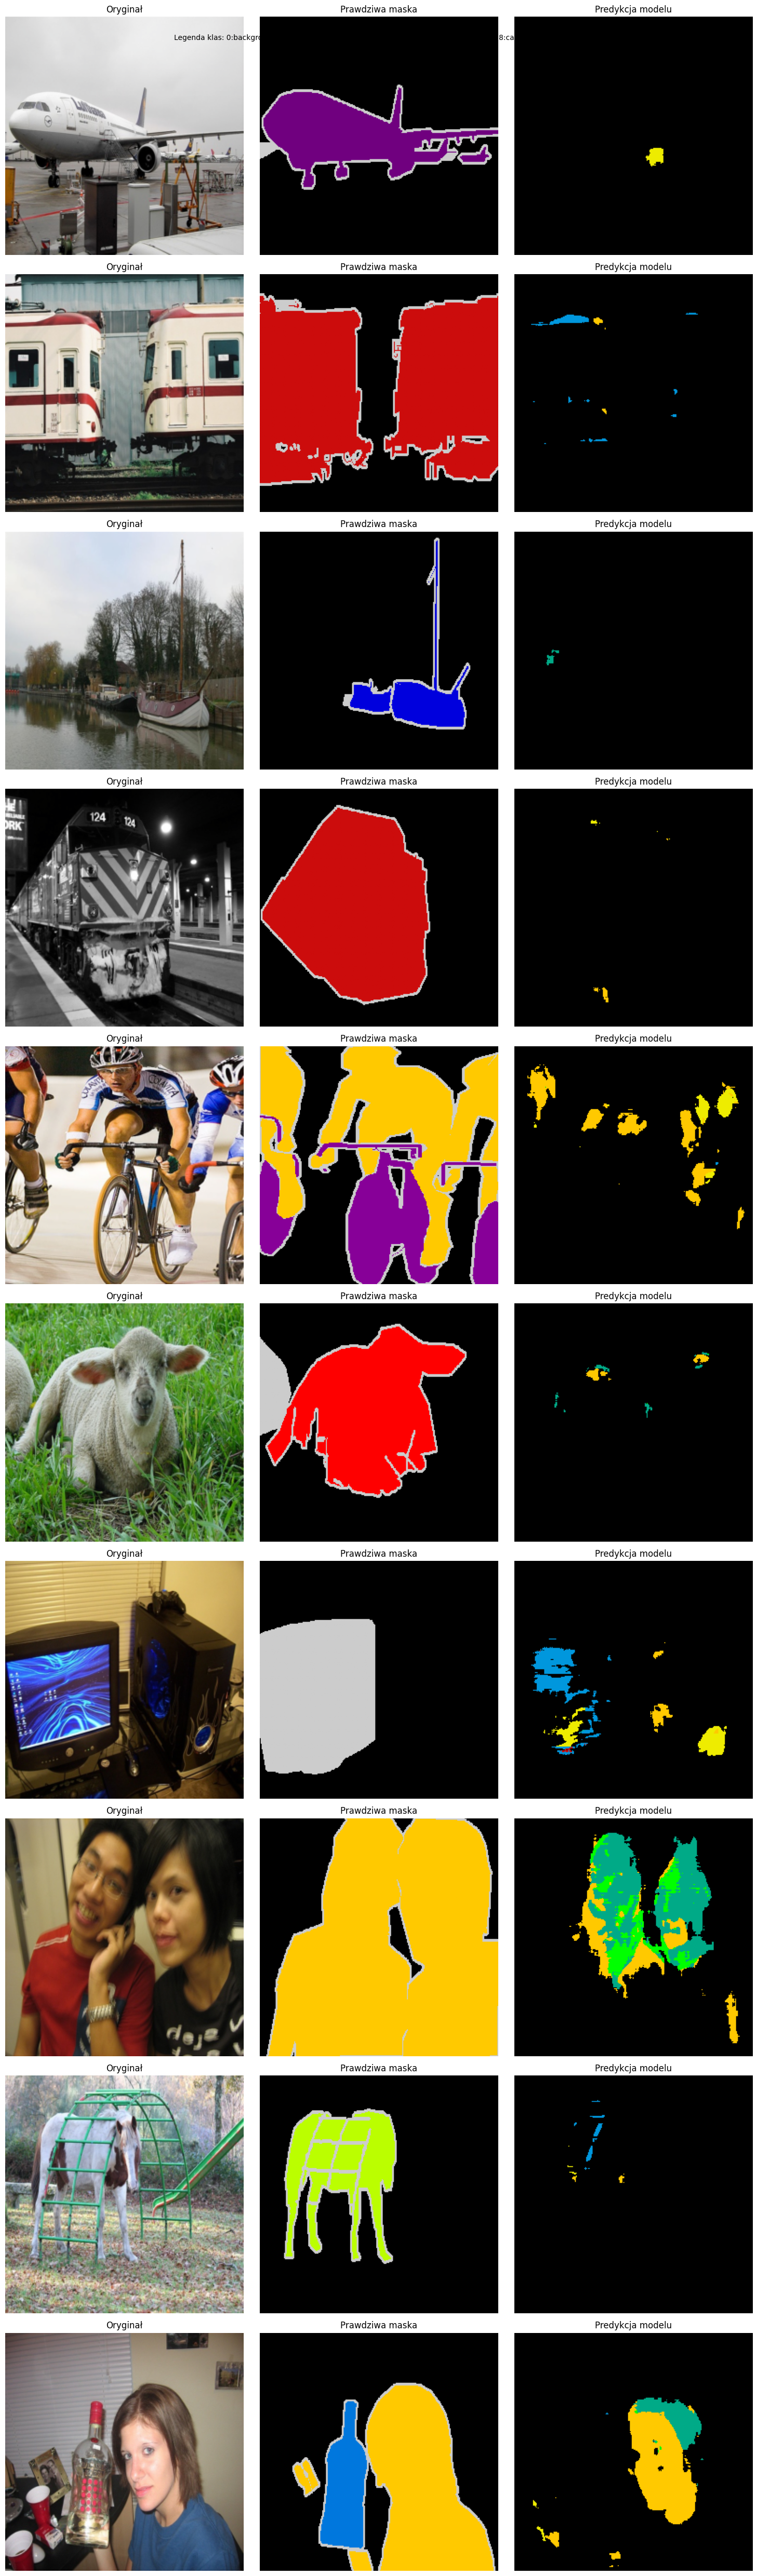

In [16]:
VOC_CLASSES = [
    'background', 'aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car', 'cat', 'chair', 'cow',
    'diningtable', 'dog', 'horse', 'motorbike', 'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor'
]

def visualize_predictions(model, dataset, device, num_samples=10):
    model.eval()
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5 * num_samples))

    with torch.no_grad():
        for i in range(num_samples):
            img, mask = dataset[i]
            input_batch = img.unsqueeze(0).to(device)
            logits = model(input_batch)
            preds = logits.argmax(dim=1).cpu().squeeze(0)

            # Obraz oryginalny
            img_display = img.permute(1, 2, 0).numpy() * IMAGENET_STD + IMAGENET_MEAN
            img_display = np.clip(img_display, 0, 1)

            axes[i, 0].imshow(img_display)
            axes[i, 0].set_title("Oryginał")

            # Prawdziwa maska
            axes[i, 1].imshow(mask, cmap='nipy_spectral', vmin=0, vmax=20)
            axes[i, 1].set_title("Prawdziwa maska")

            # Predykcja
            axes[i, 2].imshow(preds, cmap='nipy_spectral', vmin=0, vmax=20)
            axes[i, 2].set_title("Predykcja modelu")

            for ax in axes[i]: ax.axis('off')

    plt.suptitle("Legenda klas: " + ", ".join([f"{i}:{c}" for i, c in enumerate(VOC_CLASSES[:11])]) + "...", fontsize=10)
    plt.tight_layout()
    plt.show()

visualize_predictions(model, val_ds, device)